In [1]:
import sys, os
from jax import config

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
# config.update('jax_enable_x64', True)
sys.path.insert(0, os.path.abspath(os.path.join('..')))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from itertools import islice

from uot.problems.generators.toy_barycenter_generator import (
    ToyBarycenterGenerator,
    RoundRobinSelector,
    FixedListSelector,
    )
from uot.utils import costs
from uot.utils.notebook_helpers import barycenter_inputs
from uot.utils.generator_helpers.get_axes import get_axes
from uot.utils.generate_nd_grid import generate_nd_grid

from uot.solvers.sinkhorn.barycenter import barycenter_sinkhorn
from uot.solvers.pdlp_barycenter import PDLPBarycenterSolver
from uot.solvers.back_and_forth.barycenter import backnforth_barycenter_sqeuclidean_nd

from uot.data.measure import DiscreteMeasure


In [2]:
gen = ToyBarycenterGenerator(
    # selector=RoundRobinSelector((
    #     ('Plus', 'Star', 'Crescent'),
    #     ('GMM', 'Ring', 'Square'),
    # )),
    selector=FixedListSelector(('Plus', 'Star', 'Crescent')),
    # n_points=128,
    n_points=64,
    cost_fn=costs.cost_euclid_squared,
    num_datasets=5,
    measure_mode='discrete',
)

problem_iter = gen.generate(num_marginals=3)
problem, problem_rr = list(islice(problem_iter, 2))
problem = problem_rr


/Users/ivanzhytkevych/Desktop/uot-bench/uot/utils/generator_helpers/shapes.py:18: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  field = jnp.clip(jnp.asarray(field, dtype=jnp.float64), 0.0, None)
/Users/ivanzhytkevych/Desktop/uot-bench/.venv/lib/python3.14/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [3]:
def normalize_field(field, eps=1e-12):
    field = np.asarray(field, dtype=np.float64)
    field = np.clip(field, 0.0, None)
    total = field.sum()
    return field / total if total > eps else field


def aligned_grid_field(points, weights, grid_points, grid_shape):
    aligned = DiscreteMeasure(points=points, weights=weights).weights_on(
        grid_points, include_zeros=True
    )
    field = np.asarray(aligned).reshape(grid_shape)
    return normalize_field(field)


def plot_field(ax, field, axes=None, title='', cmap='magma', vmin=None, vmax=None):
    if axes is not None:
        extent = (
            float(axes[0][0]),
            float(axes[0][-1]),
            float(axes[1][0]),
            float(axes[1][-1]),
        )
        im = ax.imshow(
            field.T, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax
        )
    else:
        im = ax.imshow(field.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    return im


In [4]:
measures, lambdas, cost, meas_array, support = barycenter_inputs(
    problem,
    support_mode='shared',
    shared_mode='union',
    return_support=True,
)

axes = get_axes(
    dim=2,
    borders=(0.0, 1.0),
    n_points=gen.n_points,
    cell_discretization=gen.cell_discretization,
    use_jax=False,
)

grid_points = np.asarray(generate_nd_grid(axes, use_jax=False))
grid_shape = (len(axes[0]), len(axes[1]))

measure_fields = []
for measure in measures:
    points, weights = measure.to_discrete(include_zeros=True)
    measure_fields.append(
        aligned_grid_field(points, weights, grid_points, grid_shape)
    )


In [5]:
b_sinkhorn, info_sinkhorn = barycenter_sinkhorn(
    measures=meas_array,
    cost=cost,
    lambdas=lambdas,
    reg=1e-4,
    tol=1e-4,
    maxiter=400,
    return_diagnostics=True,
)

print(f"Sinkhorn iterations = {info_sinkhorn['iterations']}")
print(f"Sinkhorn error = {info_sinkhorn['error']}")

sinkhorn_field = aligned_grid_field(
    support, np.asarray(b_sinkhorn), grid_points, grid_shape
)


Sinkhorn iterations = 301
Sinkhorn error = 9.482669702265412e-05


In [ ]:
# marginals = [
#     DiscreteMeasure(points=support, weights=meas_array[i], name=f'measure_{i+1}')
#     for i in range(meas_array.shape[0])
# ]

# solver = PDLPBarycenterSolver()
# result_pdlp = solver.solve(
#     marginals=marginals,
#     costs=[cost],
#     weights=lambdas,
#     reg=1e+1,
#     maxiter=2000,
#     tol=1e-4,
# )

# b_pdlp = np.asarray(result_pdlp['barycenter'])
# print(f"PDLP iterations = {result_pdlp['iterations']}")
# print(f"PDLP error = {result_pdlp['error']}")

# pdlp_field = aligned_grid_field(
#     support, b_pdlp, grid_points, grid_shape
# )


PDLP iterations = 511
PDLP error = 8.488286403007805e-05


In [ ]:
measures_weights = [jnp.asarray(field) for field in measure_fields]

print(f"{type(measures_weights)=}")

b_bnf, diag_bnf = backnforth_barycenter_sqeuclidean_nd(
    weights=[float(x) for x in np.asarray(lambdas)],
    measures_weights=measures_weights,
    coordinates=[jnp.asarray(ax) for ax in axes],
    outer_maxiter=10,
    stopping_tol=2e-4,
    relaxation=1.0,
    transport_stepsize=1.0,
    transport_maxiter=1000,
    transport_tol=1e-4,
)

print(f"Back-and-forth iterations = {diag_bnf['iterations']}")
print(f"Back-and-forth final residual = {diag_bnf['final_residual']}")
print(f"Back-and-forth max transport error = {diag_bnf['max_transport_error']}")
print(f"Back-and-forth max marginal error = {diag_bnf['max_marginal_error']}")

bnf_field = normalize_field(np.asarray(b_bnf))


Internal: bfm converged after 130 iterations
Internal: bfm converged after 138 iterations
Internal: bfm converged after 139 iterations
Internal: bfm converged after 120 iterations
Internal: bfm converged after 120 iterations
Internal: bfm converged after 121 iterations
Back-and-forth iterations = 2
Back-and-forth final residual = 0.0
Back-and-forth max transport error = 0.3415515422821045
Back-and-forth max marginal error = 0.00021354826458264142


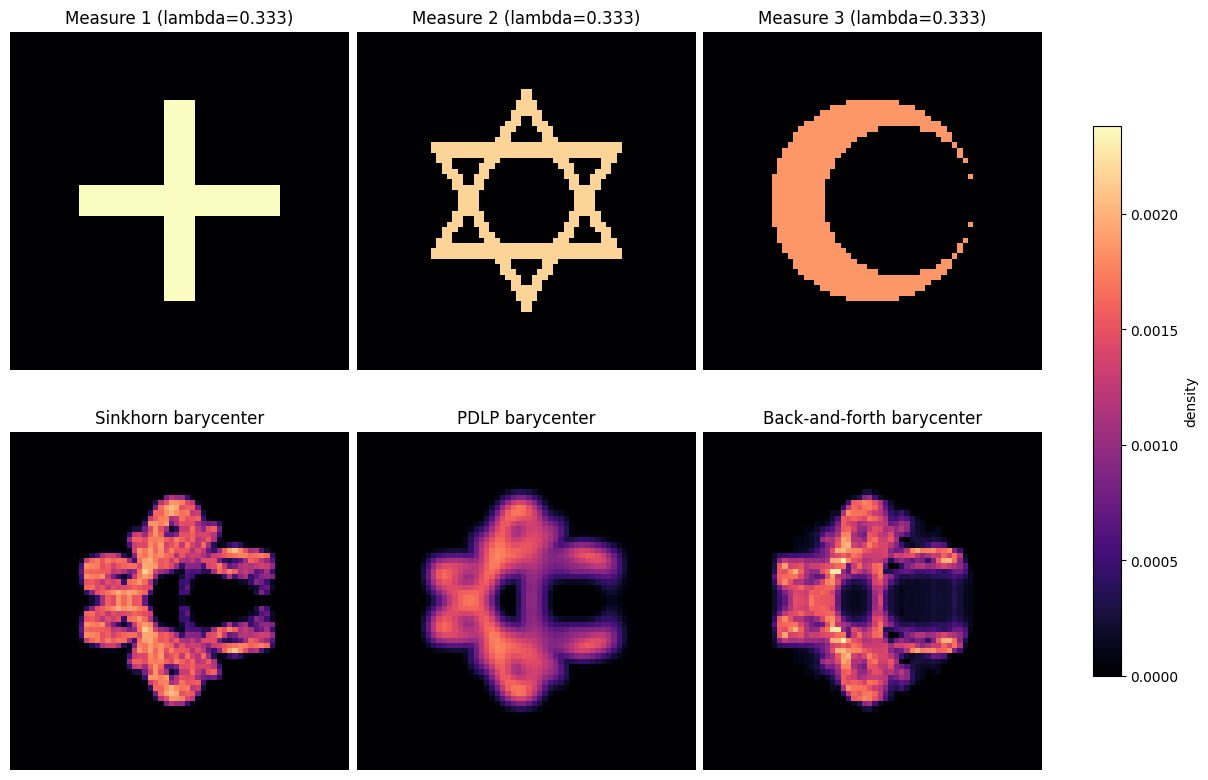

In [9]:
num_measures = len(measure_fields)
# bary_fields = [sinkhorn_field, bnf_field]
bary_fields = [sinkhorn_field, pdlp_field, bnf_field]
all_fields = measure_fields + bary_fields

vmin = min(float(np.min(f)) for f in all_fields)
vmax = max(float(np.max(f)) for f in all_fields)

ncols = max(num_measures, len(bary_fields))
fig, axes_plot = plt.subplots(2, ncols, figsize=(4 * ncols, 8), constrained_layout=True)
axes_plot = np.atleast_2d(axes_plot)

lambda_values = np.asarray(lambdas) if lambdas is not None else None
im = None

for i in range(ncols):
    ax = axes_plot[0, i]
    if i < num_measures:
        name = getattr(measures[i], 'name', '') or f'Measure {i + 1}'
        if lambda_values is not None:
            title = f"{name} (lambda={float(lambda_values[i]):.3f})"
        else:
            title = name
        im = plot_field(ax, measure_fields[i], axes=axes, title=title, vmin=vmin, vmax=vmax)
    else:
        ax.axis('off')

bary_titles = ['Sinkhorn barycenter', 'PDLP barycenter', 'Back-and-forth barycenter']
for i in range(ncols):
    ax = axes_plot[1, i]
    if i < len(bary_fields):
        im = plot_field(ax, bary_fields[i], axes=axes, title=bary_titles[i], vmin=vmin, vmax=vmax)
    else:
        ax.axis('off')

if im is not None:
    fig.colorbar(im, ax=axes_plot.ravel().tolist(), shrink=0.7, label='density')

plt.show()
